In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: d:\Programming\kaggle-portfolio\competitions\predicting-electric-vehicle-purchases


In [2]:
from src.config import (
    TARGET_COL,
    ID_COL,
    CATEGORICAL_COLS,
)

from src.data import load_data
from src.features_v2 import build_features

print("Imports successful.")

Imports successful.


In [3]:
TRAIN_PATH = PROJECT_ROOT / "data" / "train.csv"
TEST_PATH = PROJECT_ROOT / "data" / "test.csv"

train_raw, test_raw = load_data(
    TRAIN_PATH,
    TEST_PATH,
)

print("Train:", train_raw.shape)
print("Test :", test_raw.shape)

Train: (668665, 15)
Test : (286571, 14)


In [4]:
train_feat = build_features(train_raw)
test_feat = build_features(test_raw)

feature_cols = [
    c for c in train_feat.columns
    if c not in {ID_COL, TARGET_COL}
]

print("Feature count:", len(feature_cols))
print(feature_cols)

Feature count: 30
['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Anxiety_ord', 'Stations_Total', 'Stations_Difference', 'Income_per_Age', 'Income_per_Commute', 'Environmental_x_Subsidy', 'Income_x_Subsidy', 'Environmental_x_HomeCharging', 'Income_x_HomeCharging', 'Environmental_x_Anxiety', 'Income_x_Anxiety', 'Income_x_Environmental', 'Subsidy_x_Anxiety', 'Subsidy_x_HomeCharging', 'Subsidy_x_City', 'Subsidy_x_CarType', 'Environmental_x_City']


In [5]:
y = (
    train_raw[TARGET_COL]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "yes": 1,
        "no": 0,
        "1": 1,
        "0": 0,
    })
)

y = y.to_numpy(dtype=np.int8)

print("Positive rate:", y.mean())

Positive rate: 0.17464500160768098


In [6]:
OOF_PATH = PROJECT_ROOT / "outputs" / "oof_lgbm_v2.npy"

oof = np.load(OOF_PATH)

print("OOF shape:", oof.shape)
print("Target shape:", y.shape)

assert len(oof) == len(y)

print("OOF AUC:", roc_auc_score(y, oof))

OOF shape: (668665,)
Target shape: (668665,)
OOF AUC: 0.9419364195855996


In [7]:
print("Prediction statistics")
print("-" * 50)

print(f"Min       : {oof.min():.6f}")
print(f"Max       : {oof.max():.6f}")
print(f"Mean      : {oof.mean():.6f}")
print(f"Median    : {np.median(oof):.6f}")
print(f"Std       : {oof.std():.6f}")

print()
print("PR-AUC:", average_precision_score(y, oof))

Prediction statistics
--------------------------------------------------
Min       : 0.000017
Max       : 0.974155
Mean      : 0.174605
Median    : 0.017642
Std       : 0.270153

PR-AUC: 0.7575209244951405


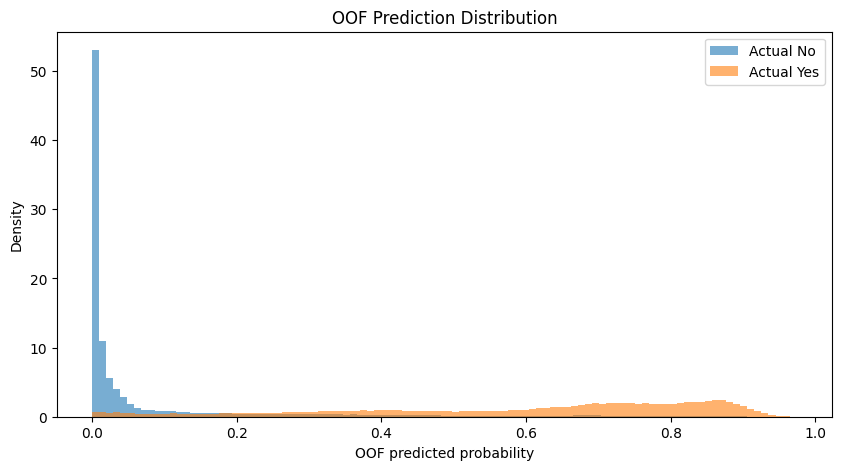

In [8]:
plt.figure(figsize=(10, 5))

plt.hist(
    oof[y == 0],
    bins=100,
    alpha=0.6,
    density=True,
    label="Actual No",
)

plt.hist(
    oof[y == 1],
    bins=100,
    alpha=0.6,
    density=True,
    label="Actual Yes",
)

plt.xlabel("OOF predicted probability")
plt.ylabel("Density")
plt.title("OOF Prediction Distribution")
plt.legend()
plt.show()

In [9]:
analysis = train_feat.copy()

analysis["_y"] = y
analysis["_pred"] = oof

analysis["pred_decile"] = pd.qcut(
    analysis["_pred"],
    q=10,
    labels=False,
    duplicates="drop",
)

decile_table = (
    analysis
    .groupby("pred_decile", observed=True)
    .agg(
        count=("_y", "size"),
        actual_rate=("_y", "mean"),
        mean_prediction=("_pred", "mean"),
        min_prediction=("_pred", "min"),
        max_prediction=("_pred", "max"),
    )
    .reset_index()
)

decile_table["actual_rate_pct"] = (
    decile_table["actual_rate"] * 100
)

decile_table

,pred_decile,count,actual_rate,mean_prediction,min_prediction,max_prediction,actual_rate_pct
0,0,66867,0.000150,0.000257,0.000017,0.000429,0.014955
1,1,66866,0.000598,0.000721,0.000429,0.001175,0.059821
2,2,66867,0.002752,0.002315,0.001175,0.003850,0.275173
3,3,66866,0.006461,0.006095,0.003851,0.008437,0.646068
4,4,66867,0.012383,0.012094,0.008437,0.017642,1.238279
5,5,66866,0.028280,0.028102,0.017642,0.042180,2.828044
6,6,66866,0.084572,0.085346,0.042180,0.155581,8.457213
7,7,66867,0.268010,0.268503,0.155589,0.387672,26.800963
8,8,66866,0.539990,0.541032,0.387681,0.689313,53.999043
9,9,66867,0.803251,0.801585,0.689322,0.974155,80.325123


In [11]:
import sys
import importlib.metadata as md

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nPackage versions:")

for package in [
    "lightgbm",
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "joblib",
]:
    try:
        print(f"{package:15s}: {md.version(package)}")
    except md.PackageNotFoundError:
        print(f"{package:15s}: NOT INSTALLED")

Python executable:
c:\Users\kaust\AppData\Local\Programs\Python\Python311\python.exe

Python version:
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]

Package versions:
lightgbm       : 4.6.0
numpy          : 1.26.4
pandas         : 2.2.2
scipy          : 1.13.0
scikit-learn   : 1.5.0
joblib         : 1.6.0


In [12]:
def subgroup_auc(
    df: pd.DataFrame,
    target: np.ndarray,
    predictions: np.ndarray,
    column: str,
) -> pd.DataFrame:

    rows = []

    values = df[column]

    for value in values.dropna().unique():

        mask = values == value

        y_sub = target[mask]
        p_sub = predictions[mask]

        if len(np.unique(y_sub)) < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(y_sub, p_sub)

        rows.append({
            "feature": column,
            "value": value,
            "n": mask.sum(),
            "positive_rate": y_sub.mean(),
            "auc": auc,
        })

    return pd.DataFrame(rows)

In [13]:
categorical_results = pd.concat(
    [
        subgroup_auc(
            train_feat,
            y,
            oof,
            col,
        )
        for col in CATEGORICAL_COLS
    ],
    ignore_index=True,
)

categorical_results.sort_values(
    "auc"
)

,feature,value,n,positive_rate,auc
12,Subsidy_Available,No,248756,0.005757,0.871861
13,Subsidy_Available,Yes,419909,0.274695,0.904401
15,Range_Anxiety_Level,Medium,62499,0.041745,0.931362
2,Gender,Other,5284,0.173732,0.936361
4,City_Type,Rural,123983,0.193389,0.937084
10,Home_Charging_Possible,Yes,462677,0.195819,0.938594
14,Range_Anxiety_Level,Low,603972,0.189027,0.939234
7,Current_Car_Type,SUV,246545,0.180953,0.940538
3,City_Type,Suburban,255377,0.180936,0.941365
9,Current_Car_Type,Truck,39223,0.156413,0.941789


In [14]:
def numerical_auc_by_quantile(
    df,
    target,
    predictions,
    column,
    q=10,
):

    temp = pd.DataFrame({
        "value": df[column].to_numpy(),
        "y": target,
        "pred": predictions,
    })

    temp["bin"] = pd.qcut(
        temp["value"],
        q=q,
        duplicates="drop",
    )

    rows = []

    for bin_value, group in temp.groupby(
        "bin",
        observed=True,
    ):

        if group["y"].nunique() < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(
                group["y"],
                group["pred"],
            )

        rows.append({
            "bin": bin_value,
            "n": len(group),
            "positive_rate": group["y"].mean(),
            "auc": auc,
            "mean_prediction": group["pred"].mean(),
        })

    return pd.DataFrame(rows)

In [15]:
for col in [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Environmental_Concern_Level",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
]:

    print("\n")
    print("=" * 70)
    print(col)
    print("=" * 70)

    display(
        numerical_auc_by_quantile(
            train_feat,
            y,
            oof,
            col,
        )
    )



Age


,bin,n,positive_rate,auc,mean_prediction
0,"(24.999, 29.0]",72933,0.189489,0.940481,0.188647
1,"(29.0, 34.0]",69408,0.160169,0.942324,0.162031
2,"(34.0, 38.0]",61837,0.170949,0.942691,0.170909
3,"(38.0, 43.0]",74419,0.177092,0.939739,0.175883
4,"(43.0, 47.0]",62401,0.173859,0.941738,0.173839
5,"(47.0, 51.0]",61748,0.176670,0.942394,0.178019
6,"(51.0, 56.0]",77954,0.200811,0.943322,0.198835
7,"(56.0, 60.0]",56066,0.167178,0.940463,0.167984
8,"(60.0, 65.0]",72931,0.159562,0.940949,0.160486
9,"(65.0, 69.0]",58968,0.163987,0.943879,0.163264




Annual_Income_USD


,bin,n,positive_rate,auc,mean_prediction
0,"(29999.999, 45980.0]",66942,0.044486,0.915205,0.044226
1,"(45980.0, 62671.0]",66861,0.084593,0.937566,0.084432
2,"(62671.0, 71832.0]",66834,0.106622,0.942312,0.106106
3,"(71832.0, 78915.0]",66844,0.131650,0.930098,0.132216
4,"(78915.0, 84880.0]",66977,0.156083,0.927636,0.157152
5,"(84880.0, 91619.0]",67013,0.179741,0.931327,0.179128
6,"(91619.0, 96748.0]",66616,0.197670,0.932465,0.196891
7,"(96748.0, 107798.0]",66854,0.219553,0.934817,0.220387
8,"(107798.0, 122349.0]",66970,0.289040,0.932163,0.288378
9,"(122349.0, 188549.0]",66754,0.337313,0.936279,0.337439




Daily_Commute_km


...

,bin,n,positive_rate,auc,mean_prediction
0,"(0.999, 2.0]",282609,0.013174,0.859954,0.013141
1,"(2.0, 3.0]",127351,0.110922,0.850921,0.110826
2,"(3.0, 4.0]",130469,0.248848,0.866332,0.248789
3,"(4.0, 5.0]",128236,0.518287,0.873194,0.518309




Charging_Stations_Near_Home


,bin,n,positive_rate,auc,mean_prediction
0,"(-0.001, 1.0]",138042,0.191471,0.938987,0.190953
1,"(1.0, 2.0]",101547,0.188041,0.938226,0.187631
2,"(2.0, 3.0]",58845,0.161543,0.943839,0.162948
3,"(3.0, 4.0]",53692,0.158478,0.941771,0.160008
4,"(4.0, 5.0]",52986,0.168516,0.944333,0.166638
5,"(5.0, 7.0]",113146,0.165618,0.942955,0.166441
6,"(7.0, 8.0]",20816,0.162711,0.945399,0.161672
7,"(8.0, 11.0]",66119,0.168802,0.944237,0.168367
8,"(11.0, 14.0]",63472,0.173651,0.944305,0.173311




Charging_Stations_Near_Work


,bin,n,positive_rate,auc,mean_prediction
0,"(-0.001, 1.0]",79409,0.184765,0.938068,0.184518
1,"(1.0, 3.0]",129277,0.181386,0.939258,0.182107
2,"(3.0, 5.0]",92209,0.174386,0.943879,0.172609
3,"(5.0, 6.0]",49103,0.168768,0.942045,0.169346
4,"(6.0, 8.0]",96269,0.171769,0.941098,0.173073
5,"(8.0, 9.0]",49745,0.173646,0.945665,0.173059
6,"(9.0, 12.0]",48536,0.165300,0.945245,0.163906
7,"(12.0, 16.0]",70904,0.170329,0.943961,0.170080
8,"(16.0, 19.0]",53213,0.169451,0.942686,0.169906


In [16]:
analysis["residual"] = (
    analysis["_y"] - analysis["_pred"]
)

analysis["abs_residual"] = (
    analysis["residual"].abs()
)

analysis["signed_residual"] = (
    analysis["residual"]
)

analysis[
    [
        ID_COL,
        TARGET_COL,
        "_y",
        "_pred",
        "residual",
        "abs_residual",
    ]
].sort_values(
    "abs_residual",
    ascending=False,
).head(50)

,id,Will_Buy_EV,_y,_pred,residual,abs_residual
521834,521834,1,1,0.000191,0.999809,0.999809
236658,236658,1,1,0.000198,0.999802,0.999802
528318,528318,1,1,0.000209,0.999791,0.999791
656804,656804,1,1,0.000268,0.999732,0.999732
105128,105128,1,1,0.000277,0.999723,0.999723
532292,532292,1,1,0.000313,0.999687,0.999687
4740,4740,1,1,0.000317,0.999683,0.999683
520419,520419,1,1,0.000319,0.999681,0.999681
513302,513302,1,1,0.000335,0.999665,0.999665
590440,590440,1,1,0.000336,0.999664,0.999664


In [17]:
hard_positive = (
    analysis[analysis["_y"] == 1]
    .sort_values("_pred")
    .head(100)
)

hard_positive[
    [
        ID_COL,
        "_y",
        "_pred",
        "Annual_Income_USD",
        "Environmental_Concern_Level",
        "Subsidy_Available",
        "Range_Anxiety_Level",
        "Home_Charging_Possible",
        "Age",
        "Daily_Commute_km",
    ]
].head(50)

,id,_y,_pred,Annual_Income_USD,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Home_Charging_Possible,Age,Daily_Commute_km
521834,521834,1,0.000191,82872.0,1,No,Low,Yes,31,38.5
236658,236658,1,0.000198,91338.0,1,No,Low,No,25,39.5
528318,528318,1,0.000209,82633.0,1,No,Low,Yes,30,50.1
656804,656804,1,0.000268,91883.0,1,No,Medium,No,39,46.3
105128,105128,1,0.000277,107819.0,1,No,Low,Yes,49,5.0
532292,532292,1,0.000313,72716.0,2,No,Low,Yes,25,27.4
4740,4740,1,0.000317,51808.0,1,Yes,Medium,No,47,5.0
520419,520419,1,0.000319,144943.0,1,No,Low,No,27,30.8
513302,513302,1,0.000335,30000.0,2,No,Low,Yes,65,28.2
590440,590440,1,0.000336,125664.0,2,No,Low,Yes,27,67.7


In [18]:
hard_negative = (
    analysis[analysis["_y"] == 0]
    .sort_values("_pred", ascending=False)
    .head(100)
)

hard_negative[
    [
        ID_COL,
        "_y",
        "_pred",
        "Annual_Income_USD",
        "Environmental_Concern_Level",
        "Subsidy_Available",
        "Range_Anxiety_Level",
        "Home_Charging_Possible",
        "Age",
        "Daily_Commute_km",
    ]
].head(50)

,id,_y,_pred,Annual_Income_USD,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Home_Charging_Possible,Age,Daily_Commute_km
607627,607627,0,0.963706,149380.0,5,Yes,Low,Yes,69,5.0
479106,479106,0,0.961017,165514.0,5,Yes,Low,Yes,44,37.2
203943,203943,0,0.960626,168218.0,5,Yes,Low,Yes,45,12.3
224159,224159,0,0.957993,166791.0,5,Yes,Low,Yes,51,58.2
401277,401277,0,0.957938,167594.0,5,Yes,Low,Yes,61,28.6
551582,551582,0,0.957111,165523.0,5,Yes,Low,Yes,27,58.9
8056,8056,0,0.956438,166587.0,5,Yes,Low,No,48,16.2
617748,617748,0,0.953364,169619.0,5,Yes,Low,No,49,5.0
374106,374106,0,0.948603,129767.0,5,Yes,Low,Yes,49,15.1
42856,42856,0,0.948206,169619.0,5,Yes,Low,Yes,41,52.4


In [19]:
compare_cols = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level",
]

comparison = pd.DataFrame({
    "hard_positive_mean": hard_positive[compare_cols].mean(),
    "hard_negative_mean": hard_negative[compare_cols].mean(),
})

comparison

,hard_positive_mean,hard_negative_mean
Age,44.130,47.260
Annual_Income_USD,73249.840,143737.490
Daily_Commute_km,32.402,27.962
Number_of_Cars_Owned,1.700,1.740
Charging_Stations_Near_Home,5.340,4.810
Charging_Stations_Near_Work,7.370,7.610
Environmental_Concern_Level,1.980,5.000


In [20]:
for col in CATEGORICAL_COLS:

    print("\n", "=" * 60)
    print(col)

    hp = (
        hard_positive[col]
        .value_counts(normalize=True)
        .rename("hard_positive")
    )

    hn = (
        hard_negative[col]
        .value_counts(normalize=True)
        .rename("hard_negative")
    )

    display(
        pd.concat(
            [hp, hn],
            axis=1,
        ).fillna(0)
    )


Gender


,hard_positive,hard_negative
Gender,,
Male,0.59,0.42
Female,0.41,0.57
Other,0.00,0.01



City_Type


,hard_positive,hard_negative
City_Type,,
Urban,0.49,0.41
Suburban,0.37,0.36
Rural,0.14,0.23



Current_Car_Type


...

,hard_positive,hard_negative
Home_Charging_Possible,,
Yes,0.61,0.83
No,0.39,0.17



Subsidy_Available


,hard_positive,hard_negative
Subsidy_Available,,
No,0.63,0.0
Yes,0.37,1.0



Range_Anxiety_Level


,hard_positive,hard_negative
Range_Anxiety_Level,,
Low,0.82,1.0
Medium,0.18,0.0


In [21]:
mod_features = pd.DataFrame(index=train_feat.index)

for col in [
    "Daily_Commute_km",
    "Annual_Income_USD",
    "Age",
]:

    for mod in [2, 3, 5, 10, 100]:

        mod_features[
            f"{col}_mod_{mod}"
        ] = (
            train_feat[col] % mod
        )

mod_features.head()

,Daily_Commute_km_mod_2,Daily_Commute_km_mod_3,Daily_Commute_km_mod_5,Daily_Commute_km_mod_10,Daily_Commute_km_mod_100,Annual_Income_USD_mod_2,Annual_Income_USD_mod_3,Annual_Income_USD_mod_5,Annual_Income_USD_mod_10,Annual_Income_USD_mod_100,Age_mod_2,Age_mod_3,Age_mod_5,Age_mod_10,Age_mod_100
0,1.4,2.4,3.4,3.4,23.4,1.0,1.0,2.0,7.0,87.0,0,0,1,6,66
1,1.0,2.0,0.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0,2,3,8,38
2,0.8,0.8,1.8,6.8,36.8,1.0,0.0,4.0,9.0,89.0,0,2,1,6,26
3,1.7,2.7,3.7,3.7,23.7,0.0,2.0,0.0,0.0,80.0,0,0,1,6,66
4,0.8,2.8,0.8,0.8,50.8,0.0,1.0,3.0,8.0,98.0,0,0,4,4,54


In [22]:
for col in mod_features.columns:

    temp = pd.DataFrame({
        "feature": mod_features[col],
        "y": y,
        "pred": oof,
    })

    temp["residual"] = (
        temp["y"] - temp["pred"]
    )

    grouped = (
        temp.groupby("feature")
        .agg(
            n=("y", "size"),
            target_rate=("y", "mean"),
            mean_prediction=("pred", "mean"),
            mean_residual=("residual", "mean"),
        )
    )

    grouped["residual_abs"] = (
        grouped["mean_residual"].abs()
    )

    print(
        col,
        "max abs mean residual:",
        grouped["residual_abs"].max(),
    )

Daily_Commute_km_mod_2 max abs mean residual: 0.05266706159397283
Daily_Commute_km_mod_3 max abs mean residual: 0.15685478737153682
Daily_Commute_km_mod_5 max abs mean residual: 0.15685478737153682
Daily_Commute_km_mod_10 max abs mean residual: 0.2662853913002054
Daily_Commute_km_mod_100 max abs mean residual: 0.6763578426170767
Annual_Income_USD_mod_2 max abs mean residual: 0.00010585562184158477
Annual_Income_USD_mod_3 max abs mean residual: 0.0006520697244003112
Annual_Income_USD_mod_5 max abs mean residual: 0.002174650308471803
Annual_Income_USD_mod_10 max abs mean residual: 0.004394408799465637
Annual_Income_USD_mod_100 max abs mean residual: 0.02094904875870978
Age_mod_2 max abs mean residual: 0.000632429792020653
Age_mod_3 max abs mean residual: 0.0006529029474923848
Age_mod_5 max abs mean residual: 0.0011701863547800442
Age_mod_10 max abs mean residual: 0.004014678573232292
Age_mod_100 max abs mean residual: 0.007314286871663343


In [24]:
categorical_results.sort_values("auc")

,feature,value,n,positive_rate,auc
12,Subsidy_Available,No,248756,0.005757,0.871861
13,Subsidy_Available,Yes,419909,0.274695,0.904401
15,Range_Anxiety_Level,Medium,62499,0.041745,0.931362
2,Gender,Other,5284,0.173732,0.936361
4,City_Type,Rural,123983,0.193389,0.937084
10,Home_Charging_Possible,Yes,462677,0.195819,0.938594
14,Range_Anxiety_Level,Low,603972,0.189027,0.939234
7,Current_Car_Type,SUV,246545,0.180953,0.940538
3,City_Type,Suburban,255377,0.180936,0.941365
9,Current_Car_Type,Truck,39223,0.156413,0.941789


In [25]:
def conditional_auc(
    df,
    y,
    pred,
    group_cols,
    min_count=500,
):
    temp = df[group_cols].copy()
    temp["_y"] = y
    temp["_pred"] = pred

    rows = []

    grouped = temp.groupby(
        group_cols,
        observed=True,
    )

    for group_values, group in grouped:

        if len(group) < min_count:
            continue

        if group["_y"].nunique() < 2:
            continue

        auc = roc_auc_score(
            group["_y"],
            group["_pred"],
        )

        if not isinstance(group_values, tuple):
            group_values = (group_values,)

        row = {
            col: value
            for col, value in zip(
                group_cols,
                group_values,
            )
        }

        row.update({
            "n": len(group),
            "positive_rate": group["_y"].mean(),
            "auc": auc,
        })

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .sort_values("auc")
        .reset_index(drop=True)
    )

In [26]:
conditional_auc(
    train_feat,
    y,
    oof,
    [
        "Subsidy_Available",
        "Environmental_Concern_Level",
    ],
    min_count=500,
)

,Subsidy_Available,Environmental_Concern_Level,n,positive_rate,auc
0,No,1,59674,0.000168,0.583736
1,No,2,52816,0.000492,0.675669
2,No,3,52500,0.003029,0.685573
3,No,4,50199,0.008088,0.687996
4,Yes,1,87802,0.009385,0.702416
5,No,5,33567,0.024756,0.728856
6,Yes,2,82317,0.034780,0.733706
7,Yes,3,74851,0.186597,0.734012
8,Yes,4,80270,0.399414,0.741536
9,Yes,5,94669,0.693279,0.743329


In [27]:
temp_analysis = train_feat.copy()

temp_analysis["Income_Bin"] = pd.qcut(
    temp_analysis["Annual_Income_USD"],
    q=10,
    duplicates="drop",
)

conditional_auc(
    temp_analysis,
    y,
    oof,
    [
        "Subsidy_Available",
        "Income_Bin",
    ],
    min_count=500,
)

,Subsidy_Available,Income_Bin,n,positive_rate,auc
0,No,"(29999.999, 45980.0]",25349,0.001262,0.803853
1,No,"(96748.0, 107798.0]",23765,0.006186,0.828767
2,No,"(78915.0, 84880.0]",25583,0.004456,0.842313
3,No,"(91619.0, 96748.0]",24593,0.006953,0.842390
4,No,"(84880.0, 91619.0]",25438,0.005936,0.843751
5,No,"(71832.0, 78915.0]",26393,0.004509,0.843849
6,No,"(107798.0, 122349.0]",21763,0.011212,0.860726
7,No,"(122349.0, 188549.0]",21251,0.013646,0.865567
8,Yes,"(29999.999, 45980.0]",41593,0.070829,0.869194
9,No,"(62671.0, 71832.0]",26949,0.003859,0.873018


In [28]:
temp_analysis["Environmental_Bin"] = pd.qcut(
    temp_analysis["Environmental_Concern_Level"],
    q=5,
    duplicates="drop",
)

conditional_auc(
    temp_analysis,
    y,
    oof,
    [
        "Environmental_Bin",
        "Income_Bin",
    ],
    min_count=500,
)

,Environmental_Bin,Income_Bin,n,positive_rate,auc
0,"(2.0, 3.0]","(29999.999, 45980.0]",13613,0.024829,0.747580
1,"(3.0, 4.0]","(29999.999, 45980.0]",12913,0.063037,0.773354
2,"(0.999, 2.0]","(29999.999, 45980.0]",30456,0.002266,0.779135
3,"(4.0, 5.0]","(29999.999, 45980.0]",9960,0.176406,0.782037
4,"(2.0, 3.0]","(78915.0, 84880.0]",12935,0.094936,0.787003
5,"(2.0, 3.0]","(71832.0, 78915.0]",12976,0.080071,0.796833
6,"(2.0, 3.0]","(107798.0, 122349.0]",12074,0.202833,0.797501
7,"(2.0, 3.0]","(84880.0, 91619.0]",12755,0.110858,0.801153
8,"(2.0, 3.0]","(122349.0, 188549.0]",11577,0.237799,0.803091
9,"(3.0, 4.0]","(78915.0, 84880.0]",12791,0.220468,0.803615


In [29]:
conditional_auc(
    temp_analysis,
    y,
    oof,
    [
        "Subsidy_Available",
        "Environmental_Bin",
        "Income_Bin",
    ],
    min_count=500,
)

,Subsidy_Available,Environmental_Bin,Income_Bin,n,positive_rate,auc
0,No,"(0.999, 2.0]","(107798.0, 122349.0]",10202,0.000196,0.227108
1,No,"(2.0, 3.0]","(29999.999, 45980.0]",5317,0.000564,0.341237
2,No,"(0.999, 2.0]","(78915.0, 84880.0]",11485,0.000348,0.453249
3,No,"(2.0, 3.0]","(96748.0, 107798.0]",5042,0.004562,0.465509
4,No,"(2.0, 3.0]","(71832.0, 78915.0]",5549,0.002343,0.467861
...,...,...,...,...,...,...
74,Yes,"(4.0, 5.0]","(62671.0, 71832.0]",7051,0.569139,0.750610
75,Yes,"(0.999, 2.0]","(62671.0, 71832.0]",17981,0.011401,0.761043
76,No,"(0.999, 2.0]","(29999.999, 45980.0]",10660,0.000094,0.782906
77,No,"(0.999, 2.0]","(71832.0, 78915.0]",11699,0.000342,0.812463
